In [1]:
import bayesflow.simulation
import matplotlib
import bayesflow as bf
import tensorflow as tf
import tensorflow_probability as tfp
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

matplotlib.rcParams["figure.dpi"] = 72

/opt/anaconda3/envs/bayesflow/lib/python3.11/site-packages/bayesflow/trainers.py:27: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
def prior(D=1, mu=0.0, sigma=1.0):
    """Gaussian prior random number generator."""
    return np.random.default_rng().normal(loc=mu, scale=sigma, size=D)


def simulator(theta, n_obs=100, scale=1.0):
    """Gaussian likelihood random number generator."""
    return np.random.default_rng().normal(loc=theta, scale=scale, size=(n_obs, theta.shape[0]))


generative_model = bf.simulation.GenerativeModel(
    prior=prior, simulator=simulator, name="Generative Model: Training", simulator_is_batched=False
)

INFO:root:Performing 2 pilot runs with the Generative Model: Training model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 1)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 100, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


In [3]:
summary_net = bf.networks.DeepSet(summary_dim=10)
inference_net = bf.networks.InvertibleNetwork(num_params=1, num_coupling_layers=2)
amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net, summary_loss_fun="MMD")
trainer = bf.trainers.Trainer(generative_model=generative_model, amortizer=amortizer, memory=True)

INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [4]:
losses = trainer.train_online(epochs=15, iterations_per_epoch=500, batch_size=32)

Training epoch 15: 100%|██████████| 500/500 [00:06<00:00, 73.77it/s, Epoch: 15, Iter: 500,Loss: -0.072,W.Decay: 0.022,Avg.Loss: 0.170,Avg.W.Decay: 0.022,LR: 1.49E-11]


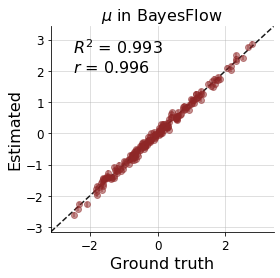

In [5]:
new_sims = trainer.configurator(trainer.generative_model(200))
posterior_draws = amortizer.sample(new_sims, n_samples=500)
fig = bf.diagnostics.plot_recovery(posterior_draws, new_sims["parameters"])

fig.axes[0].set_title(r"$\mu$ in BayesFlow", fontsize=16)
plt.show()

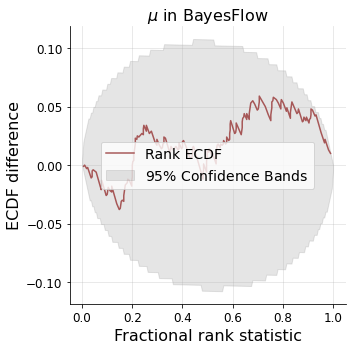

In [6]:
fig = bf.diagnostics.plot_sbc_ecdf(posterior_draws, new_sims["parameters"], difference=True)

fig.axes[0].set_title(r"$\mu$ in BayesFlow", fontsize=16)
plt.show()

In [7]:
def bayes_estimator(Z, mu_0=1.0, m=1.0, sigma_0=1.0, n_samples=1000):
    """
    Implements a Bayesian estimator that calculates the posterior distribution 
    based on the prior and observed data, and samples from it.

    Parameters:
    - Z: Input data, expected shape (batch_size, n_obs, 1).
    - mu_0: Prior mean.
    - m: Prior pseudo-sample size.
    - sigma_0: Prior standard deviation.
    - n_samples: Number of posterior samples to draw.

    Returns:
    - posterior_samples: 1000 samples drawn from the posterior distribution.
    """
    # Convert Z to a TensorFlow tensor (ensure dtype is float32)
    Z = tf.convert_to_tensor(Z, dtype=tf.float32)

    # Compute the mean over the observation dimension (axis=1)
    y_bar = tf.reduce_mean(Z, axis=1)  # Shape: (batch_size, 1)
    n = tf.cast(tf.shape(Z)[1], tf.float32)  # Number of observations (n_obs)

    # Compute posterior mean and standard deviation
    posterior_mean = (m * mu_0 + n * y_bar) / (m + n)  # Shape: (batch_size, 1)
    posterior_stddev = sigma_0 / tf.sqrt(m + n)  # Shape: scalar

    # Define the posterior distribution
    dist = tfp.distributions.Normal(loc=posterior_mean, scale=posterior_stddev)

    # Sample from the posterior distribution
    posterior_samples = dist.sample(n_samples).numpy()  # Shape: (n_samples, batch_size, 1)
    
    
    return posterior_samples.squeeze()  # Remove unnecessary dimensions if any


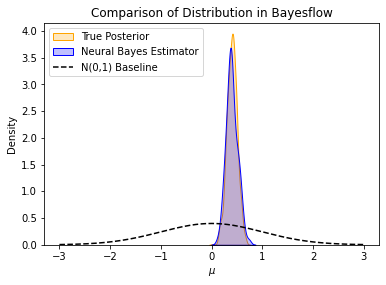

In [8]:
n_obs = 100  # Number of samples
true_miu = 0.4  # True mean
true_sigma = 1  # True standard deviation
obs_data = np.random.normal(loc=true_miu, scale=true_sigma, size=(n_obs, 1)).astype(np.float32)
Z = obs_data  # Remember the value of Z, it will be used later
obs_data = obs_data[np.newaxis, :, :]  # Reshape to (1, n_obs, 1)

summary_vector = summary_net(obs_data).numpy()

posterior_samples = amortizer.sample({"summary_conditions": obs_data}, n_samples=100)

reference_posterior = bayes_estimator(obs_data)

plt.figure(figsize=(6, 4))

# Plot true posterior
sns.kdeplot(reference_posterior, label="True Posterior", fill=True, color="orange")

# Plot inferred posterior
sns.kdeplot(posterior_samples[:, 0], label="Neural Bayes Estimator", fill=True, color="blue")

# Generate density curve for N(0,1)
x = np.linspace(-3, 3, 1000)  # Set x-axis range
y = stats.norm.pdf(x, loc=0, scale=1)  # Compute probability density of N(0,1)

# Plot N(0,1) curve on the same graph
plt.plot(x, y, label="N(0,1) Baseline", color="black", linestyle="--")

# Axis labels and legend
plt.xlabel(r"$\mu$")
plt.ylabel("Density")
plt.title("Comparison of Distribution in Bayesflow")
plt.legend()
plt.show()
